     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


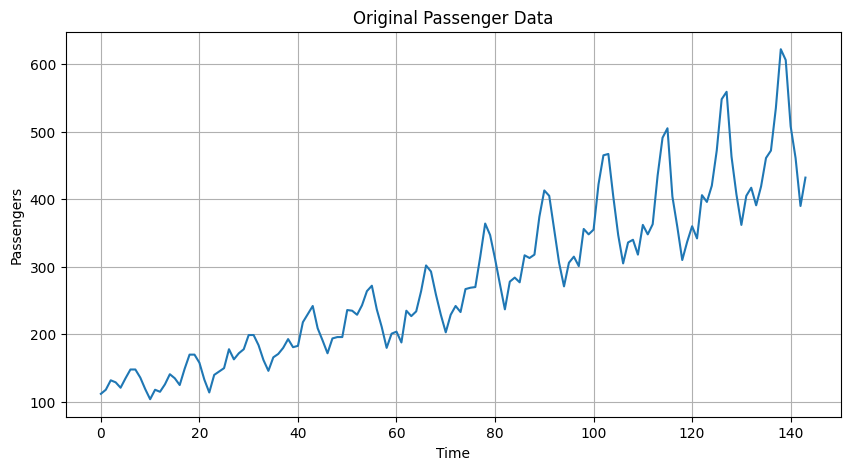

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0976 - val_loss: 0.3861
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0776 - val_loss: 0.3174
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0580 - val_loss: 0.2518
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0421 - val_loss: 0.1858
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0275 - val_loss: 0.1265
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0181 - val_loss: 0.0748
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0128 - val_loss: 0.0456
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0122 - val_loss: 0.0370
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0112 - val_loss: 0.0383
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0098 - val_loss: 0.0374
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0088 - val_loss: 0.0323
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0082 - val_loss: 0.0286
Epoch 13/50


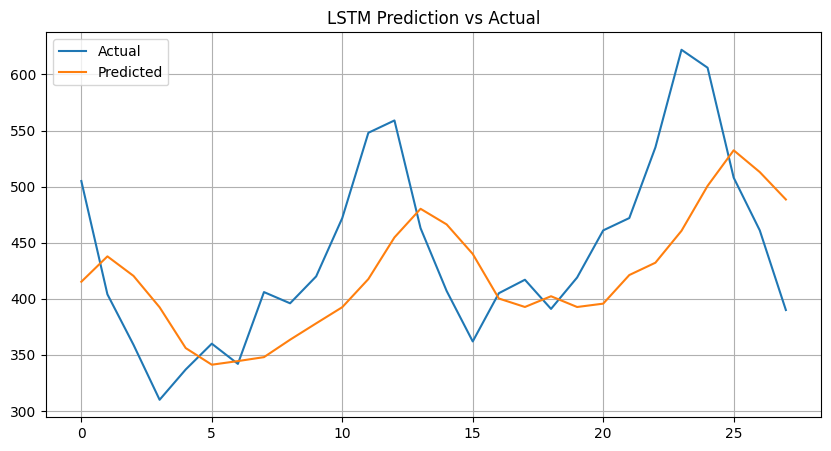

MSE: 4990.977513041879
RMSE: 70.64685069443563


In [1]:
# ============================================================
# EXP 9: RNN / LSTM for Time Series Prediction
# ============================================================

# STEP 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# STEP 2: Load Dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

print(df.head())

# Plot original data
plt.figure(figsize=(10,5))
plt.plot(df['Passengers'])
plt.title("Original Passenger Data")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.grid()
plt.show()


# STEP 3: Preprocessing
data = df['Passengers'].values.reshape(-1,1)

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# STEP 4: Create Sequences
def create_dataset(dataset, time_step=5):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 5
X, y = create_dataset(data_scaled, time_step)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

# STEP 5: Train-Test Split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# STEP 6: Build LSTM Model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(time_step,1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# STEP 7: Train Model
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_data=(X_test, y_test))

# STEP 8: Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Inverse scaling
train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# STEP 9: Plot Results
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual")
plt.plot(test_pred, label="Predicted")
plt.title("LSTM Prediction vs Actual")
plt.legend()
plt.grid()
plt.show()

# STEP 10: Error Calculation
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test_actual, test_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)